In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

In [9]:
df = pd.read_csv("../Dataset/Global_Cybersecurity_Threats_2015-2024.csv")

## Data Analysis 

In [10]:
df.shape

(3000, 10)

In [11]:
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [12]:
df.tail()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
2995,UK,2021,Ransomware,Government,51.42,190694,Unknown,Social Engineering,Firewall,52
2996,Brazil,2023,SQL Injection,Telecommunications,30.28,892843,Hacker Group,Zero-day,VPN,26
2997,Brazil,2017,SQL Injection,IT,32.97,734737,Nation-state,Weak Passwords,AI-based Detection,30
2998,UK,2022,SQL Injection,IT,32.17,379954,Insider,Unpatched Software,Firewall,9
2999,Germany,2021,SQL Injection,Retail,48.20,480984,Unknown,Zero-day,VPN,64


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (in Million $)        3000 non-null   float64
 5   Number of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (in Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


In [15]:
df.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


## Check Missing Values

In [17]:
df.isnull().sum()

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("(", "")
      .str.replace(")", "")
      .str.replace("$", "", regex=False)
)

In [20]:
df.columns

Index(['country', 'year', 'attack_type', 'target_industry',
       'financial_loss_in_million_', 'number_of_affected_users',
       'attack_source', 'security_vulnerability_type',
       'defense_mechanism_used', 'incident_resolution_time_in_hours'],
      dtype='object')

## Exploratory Data Analysis

## Count incidents per year
How have cybersecurity incidents changed over the years

In [21]:
yearly_incidents = df["year"].value_counts().sort_index()

yearly_incidents

year
2015    277
2016    285
2017    319
2018    310
2019    263
2020    315
2021    299
2022    318
2023    315
2024    299
Name: count, dtype: int64

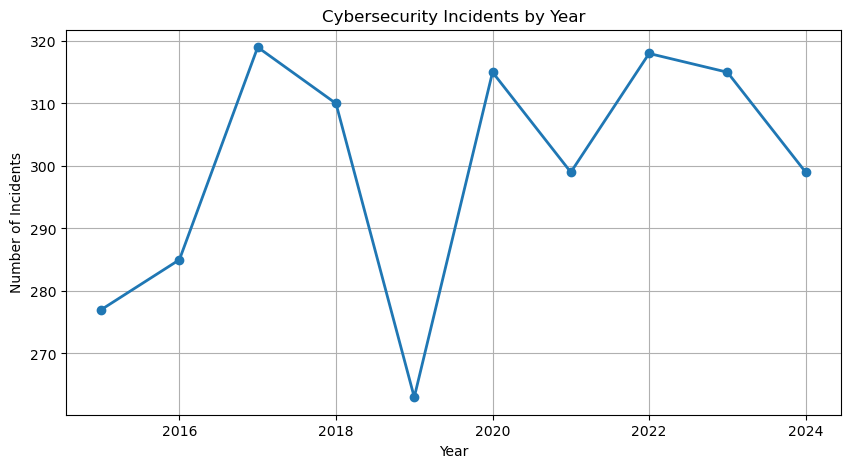

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_incidents.index,
    yearly_incidents.values,
    marker="o",
    linewidth=2
)

plt.title("Cybersecurity Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")

plt.grid(True)

plt.show()

## Top 10 Countries by Cybersecurity Incidents
Which countries experienced the highest number of cybersecurity incidents?

In [24]:
country_counts = df["country"].value_counts().head(10)

country_counts

country
UK           321
Brazil       310
India        308
France       305
Japan        305
Australia    297
Russia       295
Germany      291
USA          287
China        281
Name: count, dtype: int64

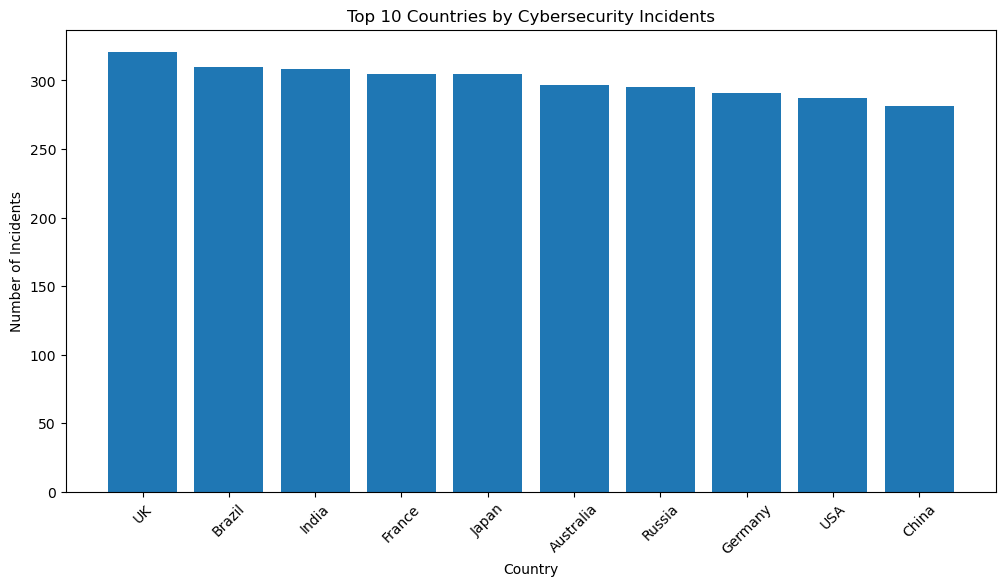

In [25]:
plt.figure(figsize=(12,6))

plt.bar(country_counts.index, country_counts.values)

plt.title("Top 10 Countries by Cybersecurity Incidents")
plt.xlabel("Country")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

## Attack Type Distribution
Which cyber attack types occur most frequently?

In [27]:
attack_counts = df["attack_type"].value_counts()

attack_counts

attack_type
DDoS                 531
Phishing             529
SQL Injection        503
Ransomware           493
Malware              485
Man-in-the-Middle    459
Name: count, dtype: int64

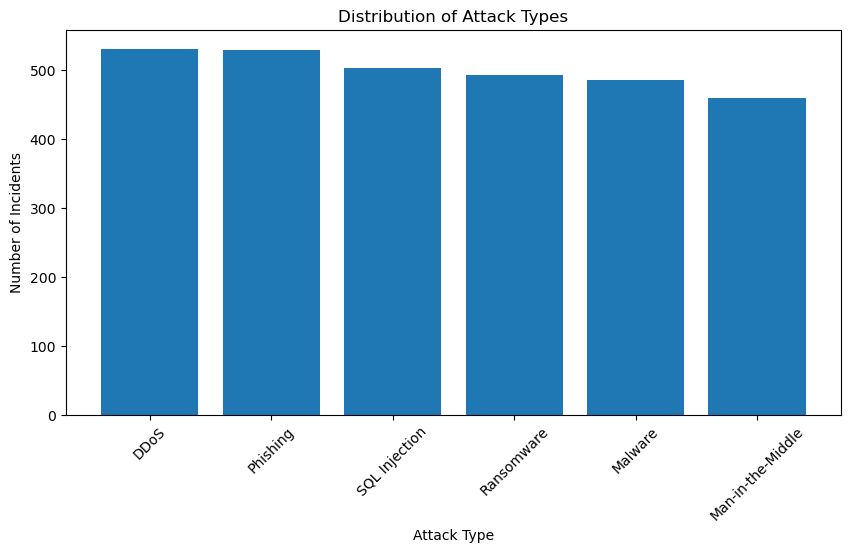

In [28]:
plt.figure(figsize=(10,5))

plt.bar(attack_counts.index, attack_counts.values)

plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

## Financial Loss by Target Industry
Which industries suffered the highest financial losses due to cyber attacks?

In [31]:
industry_loss = df.groupby("target_industry")["financial_loss_in_million_"].sum().sort_values(ascending=False)

industry_loss

target_industry
IT                    24809.83
Banking               22772.39
Government            21205.33
Retail                21119.55
Healthcare            21041.29
Telecommunications    20459.09
Education             20071.43
Name: financial_loss_in_million_, dtype: float64

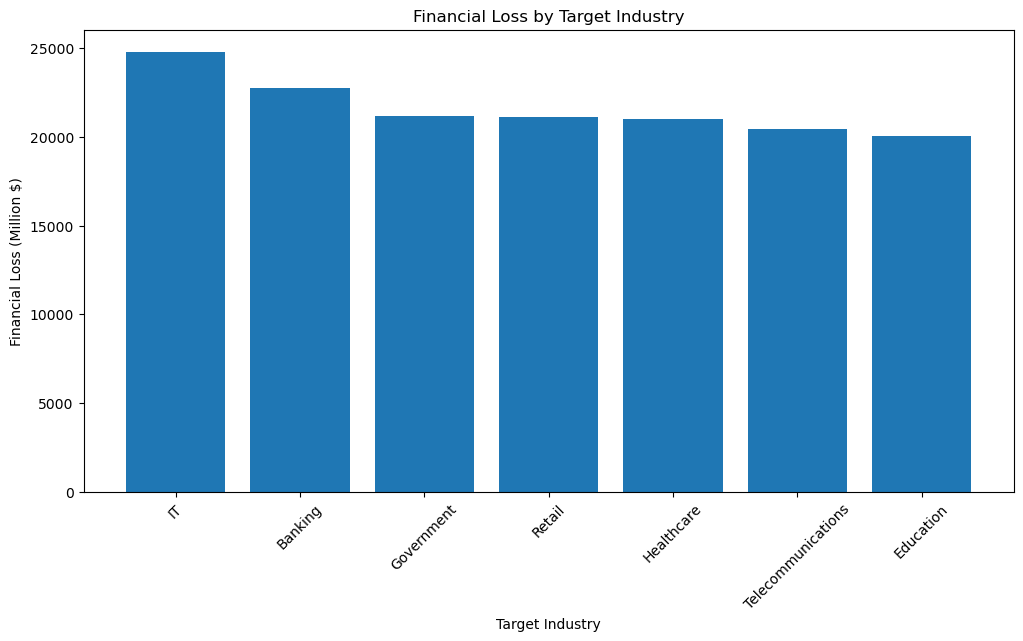

In [32]:
plt.figure(figsize=(12,6))

plt.bar(industry_loss.index, industry_loss.values)

plt.title("Financial Loss by Target Industry")
plt.xlabel("Target Industry")
plt.ylabel("Financial Loss (Million $)")

plt.xticks(rotation=45)

plt.show()

In [33]:
df.rename(
    columns={
        "financial_loss_in_million_": "financial_loss_in_million"
    },
    inplace=True
)

## Target Industry Distribution

In [35]:
industry_count = df["target_industry"].value_counts()

industry_count

target_industry
IT                    478
Banking               445
Healthcare            429
Retail                423
Education             419
Telecommunications    403
Government            403
Name: count, dtype: int64

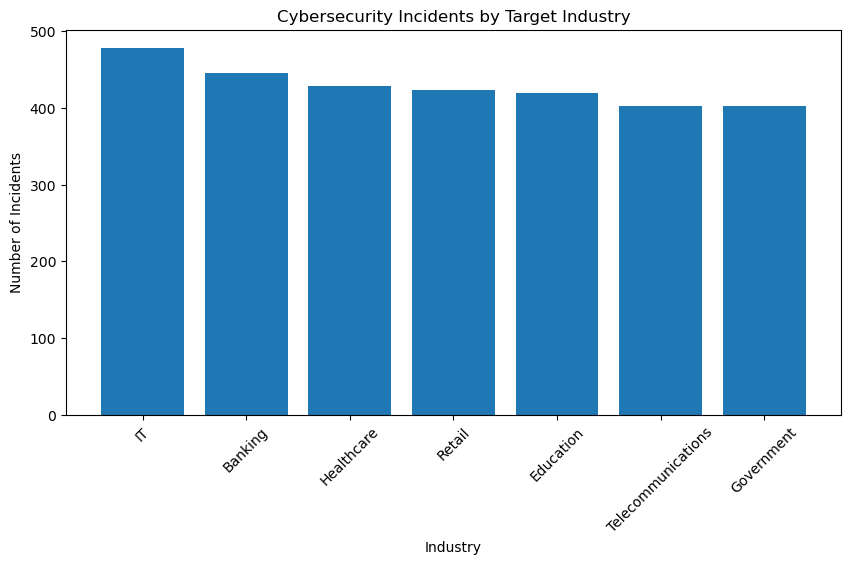

In [36]:
plt.figure(figsize=(10,5))

plt.bar(industry_count.index, industry_count.values)

plt.title("Cybersecurity Incidents by Target Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

## Attack Source Distribution
What is the source of most cyber attacks?

In [37]:
attack_source_count = df["attack_source"].value_counts()

attack_source_count

attack_source
Nation-state    794
Unknown         768
Insider         752
Hacker Group    686
Name: count, dtype: int64

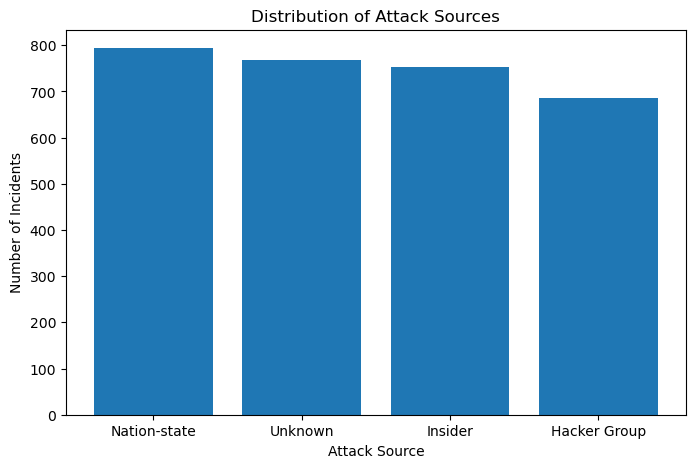

In [38]:
plt.figure(figsize=(8,5))

plt.bar(attack_source_count.index, attack_source_count.values)

plt.title("Distribution of Attack Sources")
plt.xlabel("Attack Source")
plt.ylabel("Number of Incidents")

plt.show()

## Security Vulnerability Types
Which security vulnerabilities are exploited the most?

In [40]:
vulnerability_count = df["security_vulnerability_type"].value_counts()

vulnerability_count

security_vulnerability_type
Zero-day              785
Social Engineering    747
Unpatched Software    738
Weak Passwords        730
Name: count, dtype: int64

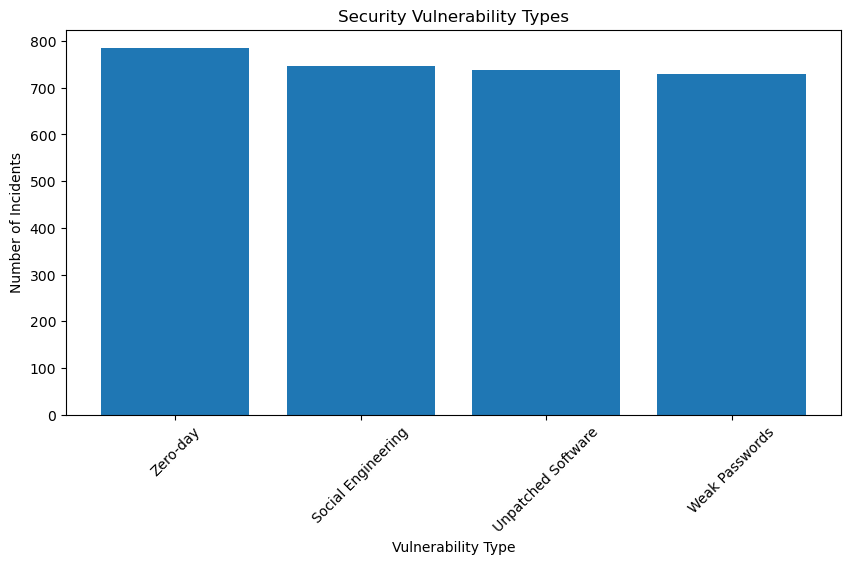

In [41]:
plt.figure(figsize=(10,5))

plt.bar(vulnerability_count.index, vulnerability_count.values)

plt.title("Security Vulnerability Types")
plt.xlabel("Vulnerability Type")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

## Defense Mechanism Used
Which defense mechanisms are most commonly used?

In [43]:
defense_count = df["defense_mechanism_used"].value_counts()

defense_count

defense_mechanism_used
Antivirus             628
VPN                   612
Encryption            592
Firewall              585
AI-based Detection    583
Name: count, dtype: int64

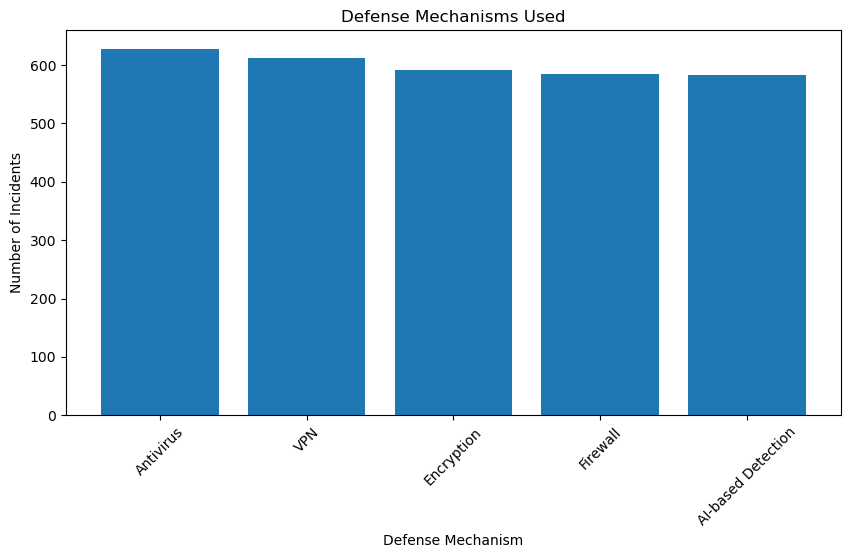

In [44]:
plt.figure(figsize=(10,5))

plt.bar(defense_count.index, defense_count.values)

plt.title("Defense Mechanisms Used")
plt.xlabel("Defense Mechanism")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

## Incident Resolution Time Distribution
How long does it usually take to resolve cybersecurity incidents?

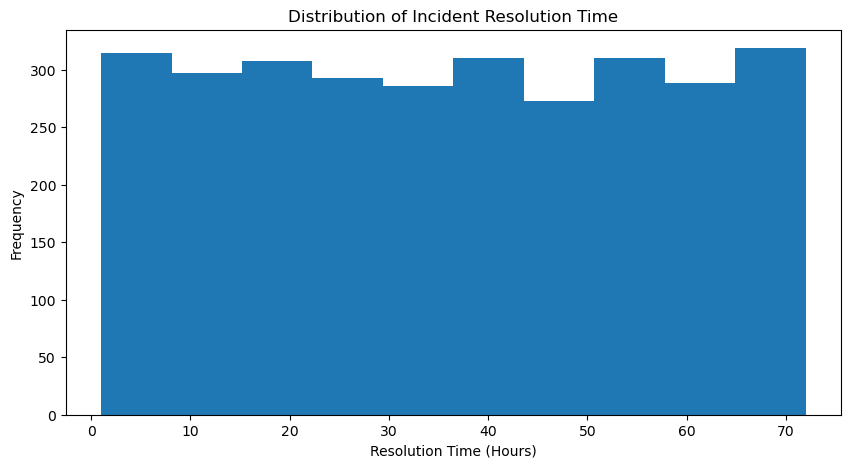

In [45]:
plt.figure(figsize=(10,5))

plt.hist(df["incident_resolution_time_in_hours"], bins=10)

plt.title("Distribution of Incident Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Frequency")

plt.show()

## Number of Affected Users Distribution
How many users are typically affected by cyber attacks?

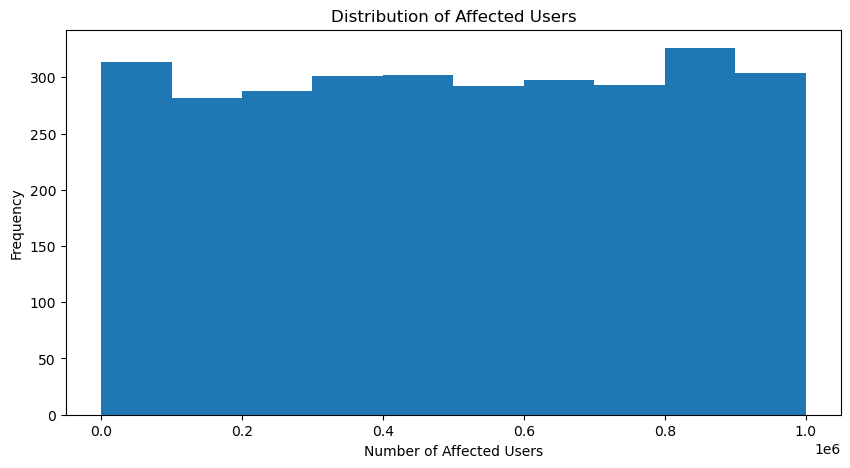

In [46]:
plt.figure(figsize=(10,5))

plt.hist(df["number_of_affected_users"], bins=10)

plt.title("Distribution of Affected Users")
plt.xlabel("Number of Affected Users")
plt.ylabel("Frequency")

plt.show()

## Correlation Analysis 
A correlation matrix helps us understand how numeric variables are related

In [47]:
correlation = df.select_dtypes(include=["int64", "float64"]).corr()

correlation

,year,financial_loss_in_million,number_of_affected_users,incident_resolution_time_in_hours
year,1.000000,0.010581,0.002317,-0.004982
financial_loss_in_million,0.010581,1.000000,0.001787,-0.012671
number_of_affected_users,0.002317,0.001787,1.000000,0.005893
incident_resolution_time_in_hours,-0.004982,-0.012671,0.005893,1.000000


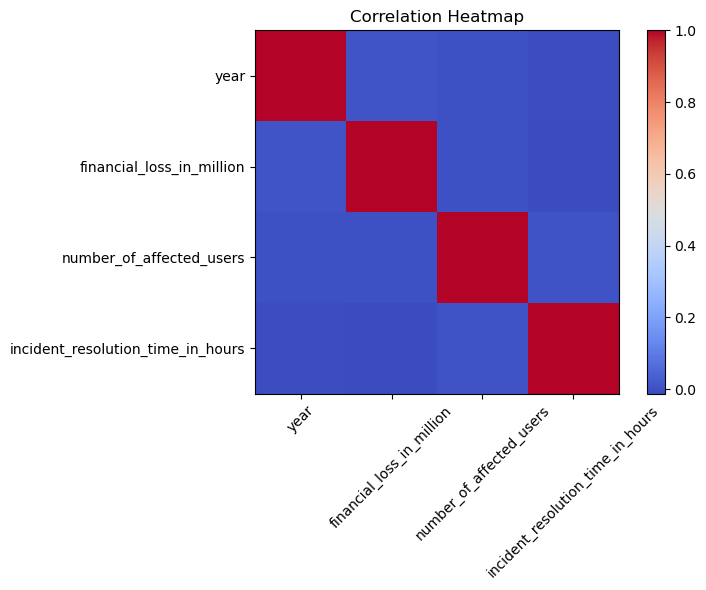

In [48]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [49]:
df.to_csv("cleaned_cybersecurity_threats.csv", index=False)